# Experiment: ANN Regularization
**Aim:** Apply Dropout, L2 Regularization and Batch Normalization to an ANN and compare the results with a model without regularization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

I0000 00:00:1787214520.984095   28032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load and prepare dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [3]:
# Model without regularization
def basic_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [4]:
# Model with Dropout
def dropout_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [5]:
# Model with L2 regularization
def l2_model():
    reg = tf.keras.regularizers.l2(0.001)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [6]:
# Model with Batch Normalization
def batchnorm_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
# Train all models
models = {
    'Without Regularization': basic_model(),
    'Dropout': dropout_model(),
    'L2 Regularization': l2_model(),
    'Batch Normalization': batchnorm_model()
}

histories = {}

for name, model in models.items():
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=32,
        verbose=0
    )
    histories[name] = history
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(name, "Test Accuracy:", round(accuracy * 100, 2), "%")

I0000 00:00:1787214524.229461   28032 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1787214525.859375   28175 service.cc:153] XLA service 0x7ed3e8031fd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787214525.859439   28175 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787214525.883894   28175 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787214526.049123   28175 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787214526.058979   28175 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1649__.9
I0000 00:00:1787214527.612806   28175 device_compil

Without Regularization Test Accuracy: 95.61 %


I0000 00:00:1787214537.591967   28174 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6765__.11
I0000 00:00:1787214539.710265   28175 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6765__.11


Dropout Test Accuracy: 96.49 %


I0000 00:00:1787214548.912507   28174 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11845__.12
I0000 00:00:1787214549.928239   28175 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11845__.12


L2 Regularization Test Accuracy: 95.61 %


I0000 00:00:1787214559.234761   28175 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17662__.21
I0000 00:00:1787214561.115709   28174 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17662__.21


Batch Normalization Test Accuracy: 95.61 %


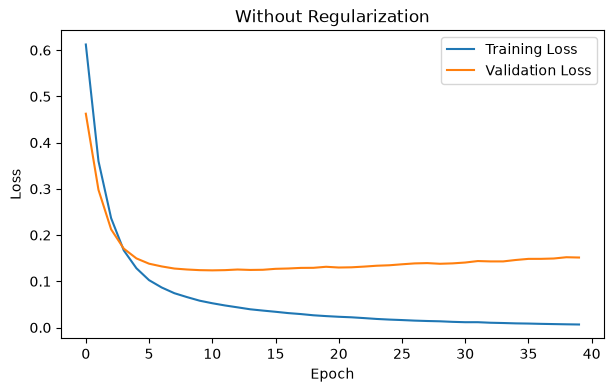

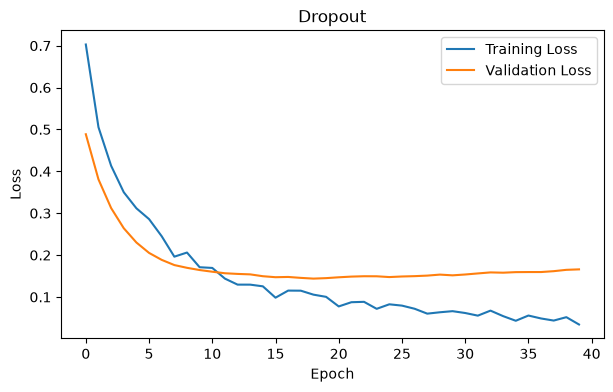

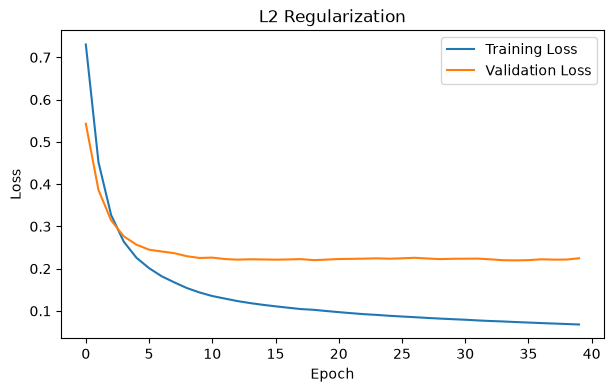

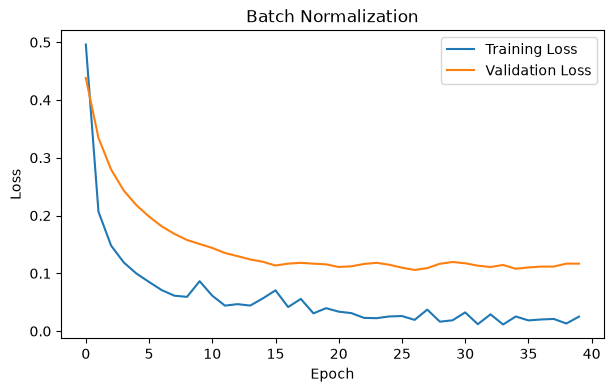

In [8]:
# Training and validation loss curves
for name, history in histories.items():
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

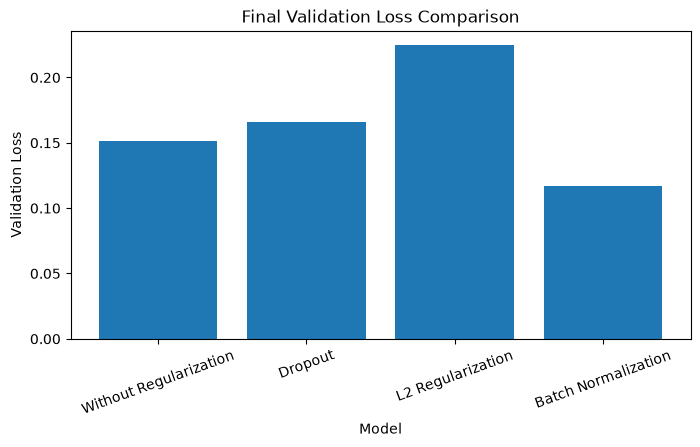

In [9]:
# Compare final validation loss
names = list(histories.keys())
val_loss = [histories[name].history['val_loss'][-1] for name in names]

plt.figure(figsize=(8, 4))
plt.bar(names, val_loss)
plt.title('Final Validation Loss Comparison')
plt.xlabel('Model')
plt.ylabel('Validation Loss')
plt.xticks(rotation=20)
plt.show()

## Observation
Compare the training and validation loss curves and the final validation loss of all four models. Regularization methods can help reduce overfitting.